In [1]:
#
import numpy as np
import xarray as xr
from matplotlib.gridspec import GridSpec
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER 
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import ConnectionPatch
import os
import pandas as pd
from matplotlib.patches import PathPatch
from matplotlib.collections import PatchCollection
from shapely.geometry import Polygon, Point
import cmaps
import matplotlib.ticker as ticker
from PyEMD import EEMD
from scipy.fft import fft, fftfreq
from scipy.integrate import simpson
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.signal import butter, filtfilt
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, boxcox
import seawater
import warnings
import tnflux
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from eofs.standard import Eof
warnings.filterwarnings('ignore')
from scipy.ndimage import gaussian_filter
from windspharm.standard import VectorWind
from windspharm.tools import prep_data, recover_data, order_latdim
from windspharm.examples import example_data_path

def smooth_gaussian(data, lat, lon, deg=5):
    dlat = np.abs(lat[1] - lat[0])
    dlon = np.abs(lon[1] - lon[0])

    sigma_lat = (deg / dlat) / 2.355
    sigma_lon = (deg / dlon) / 2.355

    smoothed = gaussian_filter(
        data,
        sigma=(0, sigma_lat, sigma_lon),
        mode='nearest'
    )

    return smoothed
    
def add_right_cax_big (ax0, ax7, pad, width) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x1 + pad, #ax0 的右边 (x1) 加上 pad 的值
        axpos2.y0,
        axpos1.x1 + pad + width,#颜色条的宽度
        axpos1.y1
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_right_cax_big_adj (ax0, ax7, pad, width,k) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x1 + pad, #ax0 的右边 (x1) 加上 pad 的值
        axpos2.y0,
        axpos1.x1 + pad + width,#颜色条的宽度
        axpos1.y0 + k*(axpos1.y1 - axpos1.y0)
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_bottom_cax_big (ax0, ax7, pad, width) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x0,
        axpos1.y0 - pad -width,
        axpos2.x1,
        axpos1.y0 - pad
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_bottom_cax_big_left (ax0, ax7, pad, width, k) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x0,
        axpos1.y0 - pad -width,
        axpos1.x0+k*(axpos2.x1-axpos1.x0),
        axpos1.y0 - pad
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax


def add_bottom_cax_big_right (ax0, ax7, pad, width, k) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos2.x1-k*(axpos2.x1-axpos1.x0),
        axpos1.y0 - pad -width,
        axpos2.x1,
        axpos1.y0 - pad
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

def add_right_cax_big_up (ax0, ax7, pad, width, k) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x1 + pad, #ax0 的右边 (x1) 加上 pad 的值
        axpos2.y0 + (1-k)*(axpos1.y1 - axpos1.y0),
        axpos1.x1 + pad + width,#颜色条的宽度
        axpos1.y1
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax


def add_right_cax_big_bo (ax0, ax7, pad, width, k) :#pad控制颜色条与 ax0 之间的间距
    axpos1=ax0. get_position ( )
    axpos2=ax7. get_position ( )
    caxpos = mpl.transforms.Bbox.from_extents( #Bbox.from_extents方法创建一个新的边界框
        axpos1.x1 + pad, #ax0 的右边 (x1) 加上 pad 的值
        axpos2.y0,
        axpos1.x1 + pad + width,#颜色条的宽度
        axpos1.y0 + k*(axpos1.y1 - axpos1.y0)
    )
    cax=ax0.figure.add_axes(caxpos) #颜色条坐标轴
    return cax

plt.rcParams['font.sans-serif']=['Helvetica']


/tmp/ipykernel_100288/4245981877.py:31: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater


In [2]:
fig_format = 'pdf'

In [3]:
def ToXr(data,lon,lat):
    res = xr.DataArray(
    data,
    dims=['lat', 'lon'],
    coords={
        'lat': lat, 
        'lon': lon
    })
    return res

def To200(da_atm):
    da_ab = xr.open_dataset('/2024data2/yangsl/Yangsl/ecs_model/ic.gamil.180x80x26.0011-01-01-00000.nc',decode_times=False
    )

    da_atm.hyam.values = da_ab.hyam.values
    da_atm.hybm.values = da_ab.hybm.values
    Z = da_atm.Z3
    pressure_at_levels = da_atm.hyam * 1e5 + da_atm.hybm * da_atm.PS
    target_pressure = 20000

    def interpolate_to_pressure(z_profile, p_profile, target_p):
        valid_idx = ~np.isnan(z_profile)
        if not valid_idx.any():
            return np.nan
        
        p_clean = p_profile[valid_idx]
        z_clean = z_profile[valid_idx]
        
        # 检查目标气压是否在范围内
        if target_p < p_clean.min() or target_p > p_clean.max():
            return np.nan
        
        # 对数插值（对于气压更准确）
        f = interp1d(
            np.log(p_clean),  # 使用对数气压
            z_clean,
            kind='linear',
            bounds_error=False,
            fill_value=np.nan
        )
        
        return float(f(np.log(target_p)))

    # 使用 apply_ufunc 进行向量化操作
    Z3_200hPa = xr.apply_ufunc(
        interpolate_to_pressure,
        Z,                          # 要插值的变量
        pressure_at_levels,           # 气压场
        input_core_dims=[['lev'], ['lev']],  # 沿着lev维度操作
        vectorize=True,               # 向量化循环
        dask='parallelized',          # 如果使用dask数组
        output_dtypes=[float],
        kwargs={'target_p': target_pressure}    # 目标气压
    )
    return Z3_200hPa

def Area_mask_m(lon, lat, area, transition=8,ew_fac=1):
    """
    lon, lat: 2D arrays
    lon in [-180, 180]
    area = [lon_min, lon_max, lat_min, lat_max]
    """

    lon2d = lon#((lon + 180) % 360) - 180
    lat2d = lat

    lon_min, lon_max, lat_min, lat_max = area

    # ---- 纬度权重（不需要周期）----
    lat_weight = np.zeros_like(lat2d, dtype=float)

    core_lat = (lat2d >= lat_min) & (lat2d <= lat_max)
    lat_weight[core_lat] = 1.0

    south_trans = (lat2d >= lat_min - transition) & (lat2d < lat_min)
    lat_weight[south_trans] = 1 - (lat_min - lat2d[south_trans]) / transition

    north_trans = (lat2d > lat_max) & (lat2d <= lat_max + transition)
    lat_weight[north_trans] = 1 - (lat2d[north_trans] - lat_max) / transition

    # ---- 经度周期处理 ----

    # 判断是否跨越 180
    cross_dateline = lon_min > lon_max

    lon_weight = np.zeros_like(lon2d, dtype=float)

    if not cross_dateline:
        # 正常情况
        core_lon = (lon2d >= lon_min) & (lon2d <= lon_max)
    else:
        # 跨越 180°
        core_lon = (lon2d >= lon_min) | (lon2d <= lon_max)

    lon_weight[core_lon] = 1.0

    # ---- 周期距离函数 ----
    def cyclic_dist(a, b):
        diff = np.abs(a - b)
        return np.minimum(diff, 360 - diff)

    # 西边界过渡
    dist_west = cyclic_dist(lon2d, lon_min)
    west_trans = (dist_west <= transition*ew_fac) & (~core_lon)
    lon_weight[west_trans] = np.maximum(
        lon_weight[west_trans],
        1 - dist_west[west_trans] / (transition * ew_fac)
    )

    # 东边界过渡
    dist_east = cyclic_dist(lon2d, lon_max)
    east_trans = (dist_east <= transition*ew_fac) & (~core_lon)
    lon_weight[east_trans] = np.maximum(
        lon_weight[east_trans],
        1 - dist_east[east_trans] / (transition * ew_fac)
    )

    # ---- 合成 ----
    mask = lat_weight * lon_weight
    mask = np.clip(mask, 0, 1)

    return mask

def rolling_corr(x, y, window):
    """
    Rolling Pearson correlation using scipy.

    Parameters
    ----------
    x, y : 1D numpy arrays
    window : int

    Returns
    -------
    r : numpy array
        Rolling correlation coefficients
    p : numpy array
        Corresponding p-values
    """

    x = np.asarray(x)
    y = np.asarray(y)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")

    n = len(x)
    r = np.empty(n - window + 1)
    p = np.empty(n - window + 1)

    for i in range(n - window + 1):
        r[i], p[i] = pearsonr(x[i:i+window], y[i:i+window])

    return r, p

In [4]:
def is_point_inside_polygon(point, polygon):
    point_obj = Point(point[0], point[1])
    return polygon.contains(point_obj) #不规则图形掩码

def Area_mask(data,lat0,lat1,lon0,lon1,Points):
    mask = data.copy()
    try:
        mask.loc[{'lat':slice(lat0,lat1),'lon':slice(lon0,lon1)}] = np.nan
    except KeyError:
        mask.loc[{'latitude':slice(lat0,lat1),'longitude':slice(lon0,lon1)}] = np.nan
    
    polygon = Polygon(Points)

    it = np.ndindex(np.squeeze(data[0].T).shape)
    for idx in it:
        lon_idx = idx[0]
        lat_idx = idx[1]
        try:
            lon = mask.lon[lon_idx]
            lat = mask.lat[lat_idx]
        except AttributeError:
            lon = mask.longitude[lon_idx]
            lat = mask.latitude[lat_idx]
        point = (lon,lat)
        if is_point_inside_polygon(point, polygon):
            mask[:,lat_idx, lon_idx] = np.nan
    return mask

def weight_mean(data, dx, dy):
    weight = dx*dy
    res = np.full_like(data[:,0,0],np.nan)
    for i in range(np.shape(data)[0]):
        w = weight.copy()
        w[np.isnan(data[i])] = np.nan
        res[i] = np.nansum(data[i,:,:]*w,axis=(-2,-1))/np.nansum(w)
    return res

def weight_mean2d(data, dx, dy):
    weight = dx*dy
    w = weight.copy()
    w[np.isnan(data)] = np.nan
    res = np.nansum(data*w)/np.nansum(w)
    return res

def Cal_mon_clim(data,n_start,n_end):
    data_bar = np.nanmean(np.reshape(np.array(data[n_start:n_end]),(30,12,np.shape(data)[1],np.shape(data)[2])),0)
    data_bar = np.tile(data_bar,(50,1,1))[:np.shape(data)[0]]
    data_prime = data - data_bar
    return data_bar, data_prime

def regress_index_to_field(index, var):
    slope = np.empty(var.shape[1:]) * np.nan
    pval  = np.empty(var.shape[1:]) * np.nan

    for i in range(var.shape[1]):
        for j in range(var.shape[2]):
            y = var[:, i, j]
            if np.all(np.isnan(y)):
                continue
            slope[i, j], _, _, pval[i, j], _ = stats.linregress(index, y)
    return slope, pval

def sel_year(data,m1,m2):
    res = np.zeros((round(np.shape(data)[0]/12),np.shape(data)[1],np.shape(data)[2]))
    for i in range(round(np.shape(data)[0]/12)):
        res[i] = np.mean(data[12*i+m1-1:12*i+m2],0)
    return res

def sel_year_1d(data,m1,m2):
    res = np.zeros(round(len(data)/12))
    for i in range(round(len(data)/12)):
        res[i] = np.mean(data[12*i+m1-1:12*i+m2])
    return res

def tscale_filter(data):
    long = gaussian_filter(data,192/1.414) #32years
    multidecade = gaussian_filter(data-long,48/1.414) #8-32years
    interan = gaussian_filter(data-long-multidecade,12/1.414)  #2years
    res = data - (long + multidecade + interan)
    return res

def norm(data):
    res = (data-np.mean(data))/np.std(data,ddof=1)
    return res

In [5]:
def OISST_series():
    fpath = '/2024data2/yangsl/Yangsl/OISST/OISST/OISST_1982-2024.nc'  # 你的海平面温度数据文件路径
    sst = xr.open_dataset(fpath)['sst']
    sst = sst.sel(time=~((sst.time.dt.month == 2) & (sst.time.dt.day == 29)))
    Points_E = [(131.5, 31.2),(130.5, 30.4),(129.5, 28.3),(129, 27.7),(128, 26.6),(125.3, 24.75),(123.75, 24.3),(123, 23.9),(131.5, 23.9)]
    Points_E1 = [(130.5, 34),(130.2, 35),(129.5, 35.5),(131.5, 35.5),(131.5, 34)]
    Points_S = [(120, 12),(119.5, 11),(118.5, 9.5),(117.5, 8.7),(117.2, 7.3),(117.2, 6),(121.5,6),(121.5,12)]
    sst_ES0 = sst.sel(lon=slice(104, 131.5),lat=slice(0,42)).squeeze()
    sst_ES = Area_mask(sst_ES0,35.5,42,127,131.5,Points_E)
    sst_ES = Area_mask(sst_ES,0,6,117.2,122,Points_E1)
    sst_ES = Area_mask(sst_ES,0,24,121.5,131.5,Points_S)
    mask_ES = np.ones_like(sst_ES[0])
    mask_ES[np.isnan(sst_ES[0])] = np.nan
    sst_EP = sst.sel(lon=slice(180, 260),lat=slice(-5,5)).resample(time='ME').mean().squeeze()
    sst_NAT = sst.sel(lon=slice(290, 350),lat=slice(5,80)).resample(time='ME').mean().squeeze()
    return sst_ES0, sst_ES, mask_ES, sst_NAT, sst_EP

In [7]:
print('Open TNFLUX')
TNFLUX1 = xr.open_dataset('./ERA5/TNFLUX_200_1.nc')
TNFLUX1 = TNFLUX1.reindex(latitude=list(reversed(TNFLUX1.latitude))
    ).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze()  
TNFLUX1 = TNFLUX1.assign_coords(
    longitude = (((TNFLUX1.longitude + 180) % 360) - 180)
).sortby('longitude')      
TNFLUX2 = xr.open_dataset('./ERA5/TNFLUX_200.nc')
TNFLUX2 = TNFLUX2.reindex(latitude=list(reversed(TNFLUX2.latitude))
).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze() 
TNFLUX2 = TNFLUX2.assign_coords(
    longitude = (((TNFLUX2.longitude + 180) % 360) - 180)
).sortby('longitude') 
print('Open PHight')
GP = xr.open_dataset('./ERA5/press_high.nc')
GP = GP.reindex(latitude=list(reversed(GP.latitude))
).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze()      
GP = GP.assign_coords(
    longitude = (((GP.longitude + 180) % 360) - 180)
).sortby('longitude')       
print('Open temp')
Temp = xr.open_dataset('./ERA5/Temp.nc')
Temp = Temp.reindex(latitude=list(reversed(Temp.latitude))
).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze()
Temp = Temp.assign_coords(
    longitude = (((Temp.longitude + 180) % 360) - 180)
).sortby('longitude')      
print('Open rain')
Rain = xr.open_dataset('./ERA5/rain_flux.nc')
Rain = Rain.reindex(latitude=list(reversed(Rain.latitude))
).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze()
Rain = Rain.assign_coords(
    longitude = (((Rain.longitude + 180) % 360) - 180)
).sortby('longitude')
rain = Rain.tp[12:].data
temp = Temp.t2m[12:].data
P = GP.z[12:].data

U200 = np.concatenate([TNFLUX1.u.data, TNFLUX2.u.data],0)
V200 = np.concatenate([TNFLUX1.v.data, TNFLUX2.v.data],0)
P200 = np.concatenate([TNFLUX1.z.data, TNFLUX2.z.data],0)

Open TNFLUX
Open PHight
Open temp
Open rain


In [8]:
uv850_0 = xr.open_dataset('./ERA5/uv850_1.nc')
uv850_1 = xr.open_dataset('./ERA5/uv850_2.nc')
uv850 = xr.concat([uv850_0,uv850_1],dim='valid_time')
uv850 = uv850.reindex(latitude=list(reversed(uv850.latitude))).sel(latitude=slice(-10,80)).interp(longitude=np.arange(0,360,2),latitude=np.arange(-10,81,2)).squeeze()
uv850 = uv850.assign_coords(longitude = (((uv850.longitude + 180) % 360) - 180)).sortby('longitude').sel(valid_time=uv850.valid_time.dt.month.isin([8, 9])).resample(valid_time='YE').mean()

In [9]:
lon = GP.longitude.data
lat = GP.latitude.data
Lon_atm, Lat_atm = np.meshgrid(lon, lat)
dx_atm = 6371*1e3*np.pi/180*np.gradient(Lon_atm,axis=1)*np.cos(np.radians(Lat_atm))
dy_atm = 6371*1e3*np.pi/180*np.gradient(Lat_atm,axis=0)

U200_bar, _ = Cal_mon_clim(U200,120-12,480-12)
V200_bar, _ = Cal_mon_clim(V200,120-12,480-12)
P200_bar, P200_prime = Cal_mon_clim(P200,120-12,480-12)
P200_prime1 = weight_mean(P200_prime[:,10:,:],dx_atm[10:,:],dy_atm[10:,:])
P200_prime_waf = P200_prime - P200_prime1[:,None,None]
P200_bar_waf = P200_bar + P200_prime1[:,None,None]
# P200_bar, P200_prime = Cal_mon_clim(P[:,-1,:,:],120-12,480-12)
# P500_bar, P500_prime = Cal_mon_clim(P[:,-2,:,:],120-12,480-12)
T_bar, T_prime = Cal_mon_clim(temp,120-12,480-12)
R_bar, R_prime = Cal_mon_clim(rain,120-12,480-12)

In [10]:
f=np.array(2*7.292e-5*np.sin(lat*np.pi/180.0)).reshape((-1,1))
streamf = P200_prime_waf/f

px = np.full_like(sel_year(U200_bar,8,9),np.nan)
py = np.full_like(sel_year(U200_bar,8,9),np.nan)
for i in range(43):
    px[i], py[i] = tnflux.tnf2d(sel_year(U200_bar,8,9)[i], sel_year(V200_bar,8,9)[i], 
    sel_year(P200_bar_waf,8,9)[i], sel_year(P200,8,9)[i], lat, lon, 200) 
mask_small = np.full_like(sel_year(U200_bar,8,9),1)
mask_small[sel_year(U200_bar,8,9)<=0] = np.nan
mask_small[(px**2+py**2)<=0.1] = np.nan
pxo = px.copy()
pyo = py.copy()
divF = np.gradient(px, axis=2)/dx_atm + np.gradient(py, axis=1)/dy_atm
pxo[np.isnan(mask_small)] = np.nan
pyo[np.isnan(mask_small)] = np.nan

In [11]:
ds = xr.open_dataset('ERA5/uv200.nc')
uwnd = ds['u'].interp(longitude=np.arange(0, 360,2),latitude=np.arange(90,-91,-2)).squeeze().data
vwnd = ds['v'].interp(longitude=np.arange(0, 360,2),latitude=np.arange(90,-91,-2)).squeeze().data
uwnd = np.concatenate([uwnd[:,:,90:],uwnd[:,:,:90]],axis=-1)
vwnd = np.concatenate([vwnd[:,:,90:],vwnd[:,:,:90]],axis=-1)
lons = np.arange(-180,180,2)
lats = np.arange(90,-91,-2)
uwnd = smooth_gaussian(uwnd, lats, lons, deg=5)
vwnd = smooth_gaussian(vwnd, lats, lons, deg=5)

uwnd, uwnd_info = prep_data(uwnd, 'tyx')
vwnd, vwnd_info = prep_data(vwnd, 'tyx')
lats, uwnd, vwnd = order_latdim(lats, uwnd, vwnd)

w = VectorWind(uwnd, vwnd)

# Compute components of rossby wave source: absolute vorticity, divergence,
# irrotational (divergent) wind components, gradients of absolute vorticity.
print('Begin Calc')
eta = w.absolutevorticity()
div = w.divergence()
uchi, vchi = w.irrotationalcomponent()
etax, etay = w.gradient(eta)

# Combine the components to form the Rossby wave source term. Re-shape the
# Rossby wave source array to the 4D shape of the wind components as they were
# read off files.
S = -eta * div - (uchi * etax + vchi * etay)
S = recover_data(S, uwnd_info)

S_89 = sel_year(S,8,9)

Begin Calc


In [12]:
sst_all, sst_ES, mask_ES, sst_NAT, sst_EP = OISST_series()

sst_ES_89 = sst_ES.sel(time=((sst_ES["time.month"] == 8) | (sst_ES["time.month"] == 9)))
base_ES_89 = np.mean(sst_ES_89.sel(time=((sst_ES_89["time.year"] < 2021) & (sst_ES_89["time.year"] > 1990))),0)
std_ES_89 = np.std(sst_ES_89.sel(time=((sst_ES_89["time.year"] < 2021) & (sst_ES_89["time.year"] > 1990))).groupby("time.year").mean(dim="time"),0)
year_ES_89 = sst_ES_89.resample(time='YE').mean()

mask_hightemp = np.full_like(year_ES_89[0],np.nan)
mask_hightemp[(np.mean(sst_ES_89[-61:],0)-base_ES_89)/std_ES_89>3] = 1
mask_hightemp[np.isnan(mask_ES)] = np.nan

Lon, Lat = np.meshgrid(sst_ES.lon, sst_ES.lat)
dx = 6371*1e3*np.pi/180*np.gradient(Lon,axis=1)*np.cos(np.radians(Lat))
dy = 6371*1e3*np.pi/180*np.gradient(Lat,axis=0)

###
mask_hightemp = mask_ES.copy()
mask_hightemp[((Lon<120.5)&(Lat<25))|(Lat<23)] = np.nan
mask_land = np.full_like(mask_hightemp,np.nan)
mask_land[np.isnan(sst_all[0])] = 1

sst_ES_mon = sst_ES.resample(time='ME').mean()
sst_ES_b, sst_ES_p = Cal_mon_clim(sst_ES_mon,9*12,39*12)
sst_EP_b, sst_EP_p = Cal_mon_clim(sst_EP,9*12,39*12)
sst_NAT_b, sst_NAT_p = Cal_mon_clim(sst_NAT,9*12,39*12)
sst_ES_p_ts = weight_mean(sst_ES_p/np.std(sst_ES_p,0)*mask_hightemp,dx,dy)
sst_EP_p_ts = weight_mean(sst_EP_p/np.std(sst_EP_p,0),np.cos(np.radians(np.meshgrid(sst_EP_p.lon, sst_EP_p.lat)[1])),np.ones_like(sst_EP_p[0]))
sst_NAT_p_ts = weight_mean(sst_NAT_p/np.std(sst_NAT_p,0),np.cos(np.radians(np.meshgrid(sst_NAT_p.lon, sst_NAT_p.lat)[1])),np.ones_like(sst_NAT_p[0]))

rain_89 = sel_year(rain,8,9)

In [13]:
sst_ocn = xr.open_dataset('/2024data2/yangsl/Yangsl/OISST/OISST/OISST_1982-2024.nc')['sst']
sst_ocn = sst_ocn.assign_coords(lon = (((sst_ocn.lon + 180) % 360) - 180)).sortby('lon')
sst_ocn = sst_ocn.resample(time='ME').mean().squeeze().interp(lon=lon,lat=lat)
sst_ocn_89 = sel_year(sst_ocn,8,9)

In [14]:
sst_index =  norm(sel_year_1d(sst_NAT_p_ts,8,9))
sst_ep_index =  norm(sel_year_1d(sst_EP_p_ts,8,9))
sst_con_index =  norm(sel_year_1d(sst_NAT_p_ts-sst_EP_p_ts,8,9))
rain_index = norm(weight_mean(sel_year(rain[:,10:21,90:108],8,9)/np.std(sel_year(rain[:,10:21,90:108],8,9),0),
    dx_atm[10:21,90:108],dy_atm[10:21,90:108]))
eu_index = norm(Eof(sel_year(P200_prime[:,15:41,60:166],8,9),
    weights=dx_atm[15:41,60:166]).pcs()[:,0])

In [15]:
slope_sst, pval_sst = regress_index_to_field(sel_year_1d(sst_ES_p_ts,8,9), sel_year(sst_ocn,8,9))
mask_p_sst = np.ones_like(pval_sst)
mask_p_sst[pval_sst>0.05] = np.nan
mask_p_sst[np.isnan(pval_sst)] = np.nan
slope_rain, pval_rain = regress_index_to_field(sel_year_1d(sst_ES_p_ts,8,9), sel_year(rain,8,9))
mask_p_rain = np.ones_like(pval_rain)
mask_p_rain[pval_rain>0.05] = np.nan
mask_p_rain[~np.isnan(pval_sst)] = np.nan


In [16]:
slope, pval = regress_index_to_field(sst_index, sel_year(P200_prime_waf,8,9))
mask_p = np.ones_like(pval)
mask_p[pval>0.05] = np.nan

slope_r, pval_r = regress_index_to_field(rain_index, sel_year(P200_prime_waf,8,9))
mask_p_r = np.ones_like(pval_r)
mask_p_r[pval_r>0.05] = np.nan

In [17]:
px_r, py_r = tnflux.tnf2d(sel_year(U200_bar,8,9)[-1], sel_year(V200_bar,8,9)[-1], sel_year(P200_bar,8,9)[-1], 
        sel_year(P200_bar,8,9)[-1]+slope_r, lat, lon, 200) 

px_t, py_t = tnflux.tnf2d(sel_year(U200_bar,8,9)[-1], sel_year(V200_bar,8,9)[-1], sel_year(P200_bar,8,9)[-1], 
        sel_year(P200_bar,8,9)[-1]+slope, lat, lon, 200) 

In [18]:
mask_small_r = np.full_like(U200_bar[0],1)
mask_small_r[sel_year(U200_bar,8,9)[-1]<=0] = np.nan
mask_small_r[(px_r**2+py_r**2)<=1e-3] = np.nan
pxo_r = px_r.copy()
pyo_r = py_r.copy()
pxo_r[np.isnan(mask_small_r)] = np.nan
pyo_r[np.isnan(mask_small_r)] = np.nan

mask_small_t = np.full_like(U200_bar[0],1)
mask_small_t[sel_year(U200_bar,8,9)[0]<=0] = np.nan
mask_small_t[(px_t**2+py_t**2)<=1e-3] = np.nan
pxo_t = px_t.copy()
pyo_t = py_t.copy()
pxo_t[np.isnan(mask_small_t)] = np.nan
pyo_t[np.isnan(mask_small_t)] = np.nan

In [19]:
# Latent Heat Release Index.
g = 9.81                 # m s-2
Lv = 2.5e6               # J kg-1 (latent heat of vaporization)
Cpw = 1846.1             # J kg-1 K-1 (cp of water vapor ~273 K)
Cw  = 4218.0             # J kg-1 K-1 (cp of liquid water)
path = "/2024data2/yangsl/Yangsl/ERA5/LHRI.nc"
var_u = "u"      # m s-1
var_v = "v"      # m s-1
var_q = "q"      # kg kg-1
var_t = "t"      # K
lev_name = "pressure_level"     # hPa
lat_name = "latitude"
lon_name = "longitude"
REGION = dict(lat_min=10, lat_max=30, lon_min=0, lon_max=35)

def cal_LHI(g, Lv, Cpw, Cw, path, var_u, var_v, var_q, var_t, REGION, lev_name, lat_name, lon_name):
    print("Loading pressure-level data (u,v,q,t)...")
    ds = xr.open_dataset(path)
    if all(REGION.get(k) is not None for k in ["lat_min","lat_max","lon_min","lon_max"]):
        # ERA5 latitude is usually descending; slice handles both orders
        ds = ds.sel(
            **{lat_name: slice(REGION["lat_max"], REGION["lat_min"])},
            **{lon_name: slice(REGION["lon_min"], REGION["lon_max"])},
        )
    ds = ds.resample(valid_time='YE').mean()
    ds = ds.reindex(latitude=list(reversed(ds.latitude)))
    u = ds[var_u]
    v = ds[var_v]
    q = ds[var_q]
    T = ds[var_t]
    lev = ds[lev_name]   # hPa
    lat = ds[lat_name]
    lon = ds[lon_name]

    A = Lv + (Cpw - Cw) * T
    Fx = u * q * A
    Fy = v * q * A

    dlat_deg = float(np.abs(lat.diff(lat_name)).mean())
    dlon_deg = float(np.abs(lon.diff(lon_name)).mean())
    lat0 = float(lat.mean())  # mean latitude for metric
    deg2m = 111_000.0
    dy = dlat_deg * deg2m
    dx = dlon_deg * deg2m * np.cos(np.deg2rad(lat))

    dFx_dx = xr.apply_ufunc(
        np.gradient, Fx, dx,
        input_core_dims=[[lon_name], []],
        output_core_dims=[[lon_name]],
        exclude_dims=set([lon_name]),
        vectorize=True, dask="parallelized")
    dFy_dy = xr.apply_ufunc(
        np.gradient, Fy, dy,
        input_core_dims=[[lat_name], []],
        output_core_dims=[[lat_name]],
        exclude_dims=set([lat_name]),
        vectorize=True, dask="parallelized")

    div_h = dFx_dx + dFy_dy   # W m-2
    print("Integrating vertically from 1000 to 100 hPa...")
    lev_pa = (ds[lev_name] * 100.0)  # hPa -> Pa
    # div_sel = div_h.where(mask, drop=True)
    # lev_sel = lev_pa.where(mask, drop=True)
    LHI_Wm2 = xr.apply_ufunc(
        np.trapz, div_h, lev_pa,
        input_core_dims=[[lev_name], [lev_name]],
        output_core_dims=[[]],
        vectorize=True, dask="parallelized"
    ) / g

    LHI_Wm2 = LHI_Wm2.rename("LHI_Wm2")
    lat = LHI_Wm2[lat_name]
    lon = LHI_Wm2[lon_name]
    weights = np.cos(np.deg2rad(lat))
    weights = xr.DataArray(weights, coords={lat_name: lat}, dims=(lat_name,))

    LHI_regmean = LHI_Wm2.weighted(weights).mean(dim=[lat_name, lon_name])
    LHI_regmean = LHI_regmean.data
    return LHI_regmean

LHI_regmean = cal_LHI(g, Lv, Cpw, Cw, path, var_u, var_v, var_q, var_t, REGION, lev_name, lat_name, lon_name)

Loading pressure-level data (u,v,q,t)...
Integrating vertically from 1000 to 100 hPa...


In [20]:
rr,pp = rolling_corr(norm(sel_year_1d(sst_ES_p_ts,8,9)), eu_index, 15)

In [21]:
sst_std = xr.open_dataset('./ecs_model/sst_clim_std.nc')#.assign_coords(lon=(sst_std.lon % 360))#.sortby('lon')
mlon,mlat = np.meshgrid(sst_std.lon.values, sst_std.lat.values)

In [22]:
mask_na = Area_mask_m(mlon,mlat,[-70,-10,5,80], transition=8, ew_fac=1)
mask_ep = Area_mask_m(mlon,mlat,[-180,-100,-5,5], transition=8, ew_fac=2)
lon_360 = sst_std.lon.values % 360
sort_idx = np.argsort(lon_360)
lon_sorted = lon_360[sort_idx]
sst_na = mask_na*sst_std.sst[6]
sst_ep = mask_ep*sst_std.sst[6]
sst_na_360 = sst_na.values[..., sort_idx]
sst_ep_360 = sst_ep.values[..., sort_idx]

In [9]:
da_atm = xr.open_dataset(
    './ecs_model/clim7.nc',decode_times=False
    ).squeeze()
z200_7 = To200(da_atm)
da_atm = xr.open_dataset(
    './ecs_model/conv_lh7.nc',decode_times=False
    ).squeeze()
z200_7_convlh = To200(da_atm)
da_atm = xr.open_dataset(
    './ecs_model/conv_hh7.nc',decode_times=False
    ).squeeze()
z200_7_convhh = To200(da_atm)

In [10]:
da_cp = xr.open_dataset(
    './ecs_model/mean_0715_0825.nc',decode_times=False
    ).squeeze()
da_cp["hyam"] = xr.DataArray(np.zeros(26),dims=("lev",),coords={"lev": da_atm.lev})
da_cp["hybm"] = xr.DataArray(np.zeros(26),dims=("lev",),coords={"lev": da_atm.lev})
z200_cp = To200(da_cp)
da_cp = xr.open_dataset(
    './ecs_model/mean_0715_0825_at.nc',decode_times=False
    ).squeeze()
da_cp["hyam"] = xr.DataArray(np.zeros(26),dims=("lev",),coords={"lev": da_atm.lev})
da_cp["hybm"] = xr.DataArray(np.zeros(26),dims=("lev",),coords={"lev": da_atm.lev})
z200_cp_na = To200(da_cp)

In [25]:
ocn_sst = xr.open_dataset('./ecs_model/sst-0715_0825.nc')['tt'].mean('time').squeeze().interp(lon=sst_ES.lon,lat=sst_ES.lat)
ocn_sst_at = xr.open_dataset('./ecs_model/sst-0715_0825_at.nc')['tt'].mean('time').squeeze().interp(lon=sst_ES.lon,lat=sst_ES.lat)
ocn_sst_diff = ocn_sst_at - ocn_sst

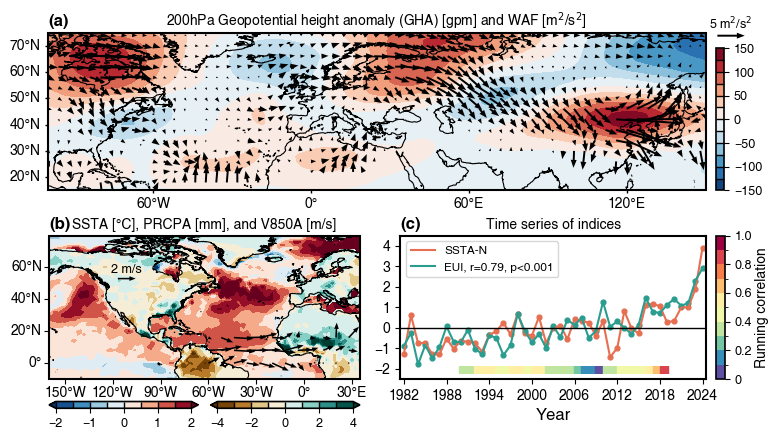

In [31]:
fig = plt.figure(figsize=(8.5, 4.5))
fig.subplots_adjust(wspace=0.2,hspace=0.3)
gs = GridSpec(2, 3 , figure=fig, width_ratios=[1, 0.45, 0.4], height_ratios=[1.1, 1])

ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree(central_longitude=0))
ax0.set_extent([-100,150,15,75], crs=ccrs.PlateCarree())
ax0.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs0 = ax0.contourf(lon,lat,sel_year(P200_prime_waf,8,9)[-1]/9.8,cmap='RdBu_r',levels=np.linspace(-150,150,13))
q = ax0.quiver(lon[::2],lat[10::2],pxo[-1,10::2,::2],pyo[-1,10::2,::2],scale=120,width=0.003,headaxislength=4,headlength=4)
ax0.quiverkey(q,1.0388,0.98,U=5,label='5 m$^2$/s$^2$',labelpos='N',labelsep=0.03,fontproperties={'size':9})
ax0.spines['geo'].set_linewidth(1.5)
gl0 =ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl0.xlabel_style = {'size': 10}
gl0.ylabel_style = {'size': 10}
ax0.set_xticks([-60, 0, 60, 120])
ax0.set_xticklabels([' ',' ',' ',' '])
ax0.set_yticks([20, 30, 40, 50, 60, 70])
ax0.set_yticklabels([' ',' ',' ',' ',' ',' '])
gl0.xlocator = ticker.FixedLocator([-60, 0, 60, 120])
gl0.ylocator = ticker.FixedLocator([20, 30,40, 50, 60, 70])
ax0.tick_params(axis='both', length=2, width=1)

ax2 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax2.set_extent([-160,35,-10,80], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs3 = ax2.contourf(lon,lat,(rain_89[-1]-np.mean(rain_89[9:39],0))*1e3,
levels=np.linspace(-4,4,9),cmap='BrBG',extend='both')
cs2 = ax2.contourf(lon,lat,(sst_ocn_89[-1]-np.mean(sst_ocn_89[9:39],0)),
levels=np.linspace(-2,2,9),cmap='RdBu_r',extend='both')
q1 = ax2.quiver(uv850.longitude[60:105:4],uv850.latitude[5:15:4],
        uv850.u[-1,5:15:4,60:105:4]-np.mean(uv850.u[:30,5:15:4,60:105:4],0),uv850.v[-1,5:15:4,60:105:4]-np.mean(uv850.v[:30,5:15:4,60:105:4],0),scale=35,width=0.005,headaxislength=4,headlength=4)
ax2.quiverkey(q1,0.25,0.7,U=2,label='2 m/s',labelpos='N',labelsep=0.03,fontproperties={'size':9})
gl2 =ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl2.left_labels = True
gl2.bottom_labels = True
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER
gl2.xlabel_style = {'size': 10}
gl2.ylabel_style = {'size': 10}
ax2.set_xticks([-150,-120,-90,-60,-30,0,30])
ax2.set_xticklabels([' ',' ',' ',' ',' ',' ',' '])
ax2.set_yticks([0, 20, 40, 60])
ax2.set_yticklabels([' ',' ',' ',' '])
gl2.xlocator = ticker.FixedLocator([-150,-120,-90,-60,-30,0,30])
gl2.ylocator = ticker.FixedLocator([0,20, 40, 60])
ax2.spines['geo'].set_linewidth(1.5)

ax3 = fig.add_subplot(gs[1, 1:])
ax3.plot(np.arange(1982,2025), norm(sel_year_1d(sst_ES_p_ts,8,9)),label='SSTA-N',c='#E76F51',lw=1.5)
ax3.plot(np.arange(1982,2025), eu_index,
        label='EUI, r=%.2f, p<0.001'%(pearsonr(eu_index,sel_year_1d(sst_ES_p_ts,8,9))[0]),c='#2A9D8F',lw=1.5)
ax3.plot(np.arange(1981,2026), np.zeros_like(np.arange(1981,2026)),c='k',lw=1)
ax3.scatter(np.arange(1982,2025), norm(sel_year_1d(sst_ES_p_ts,8,9)),s=12,c='#E76F51')
ax3.scatter(np.arange(1982,2025), eu_index,s=12,c='#2A9D8F')
ax3.set_xlim([1981.5,2024.5])
ax3.set_ylim([-2.5,4.5])
ax3.set_yticks([-2,-1,0,1,2,3,4],['−2','−1','0','1','2','3','4'],fontsize=10)
ax3.set_xticks([1982,1988,1994,2000,2006,2012,2018,2024],[1982,1988,1994,2000,2006,2012,2018,2024],fontsize=10)
ax3.set_xlabel('Year',fontsize=12)
ax3.legend(loc='upper left',ncol=1,fontsize=8.5)
ax3.spines[['top','bottom','left','right']].set_linewidth(1.5)
inset_ax = inset_axes(ax3, width="100%", height="100%", bbox_to_anchor=(1988, -2.6, 31, 0.4),bbox_transform=ax3.transData,loc="lower left")
inset_ax.set_xticks([])
inset_ax.set_yticks([])
for spine in inset_ax.spines.values():
    spine.set_visible(False)
cs_i = inset_ax.scatter(np.arange(1989,2018),np.full_like(rr,-2.5),c=rr,cmap='Spectral_r',norm=BoundaryNorm(np.linspace(0,1,11), ncolors=256, clip=True),marker='s')

cax = add_right_cax_big_adj(ax0,ax0, pad=0.012, width=0.01,k=0.9)
cb =  fig.colorbar(cs0,cax=cax,drawedges=True)
cb.set_ticks([-150,-100,-50,0,50,100,150])
cb.set_ticklabels(['−150','−100','−50','0','50','100','150'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big_left(ax2,ax2, pad=0.05, width=0.015, k=0.48)
cb =  fig.colorbar(cs2,cax=cax,drawedges=True,orientation='horizontal')
cb.set_ticks([-2,-1,0,1,2])
cb.set_ticklabels(['−2','−1','0','1','2'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)
# cb.set_label('SSTA [°C]',fontsize=10,labelpad=0)

cax = add_bottom_cax_big_right(ax2,ax2, pad=0.05, width=0.015, k=0.48)
cb =  fig.colorbar(cs3,cax=cax,drawedges=True,orientation='horizontal')
cb.set_ticks([-4,-2,0,2,4])
cb.set_ticklabels(['−4','−2','0','2','4'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)
# cb.set_label('PRCPA [mm]',fontsize=10,labelpad=0)

cax = add_right_cax_big(ax3,ax3, pad=0.012, width=0.01)
cb =  fig.colorbar(cs_i,cax=cax)
cb.set_ticks([0,0.2,0.4,0.6,0.8,1])
cb.set_ticklabels(['0','0.2','0.4','0.6','0.8','1.0'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)
cb.set_label('Running correlation',fontsize=10,labelpad=2)

ax0.set_title('(a)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax2.set_title('(b)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax3.set_title('(c)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax0.set_title('200hPa Geopotential height anomaly (GHA) [gpm] and WAF [m$^2$/s$^2$]',fontsize=10,pad=5)
ax2.set_title('SSTA [°C], PRCPA [mm], and V850A [m/s]',fontsize=10,pad=5)
ax3.set_title('Time series of indices',fontsize=10,pad=5)
fig_format = 'pdf'
fig.savefig('./ERL/Fig4.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')
fig.savefig('./ERL/Fig4.png', format='png', dpi = 300, bbox_inches='tight')

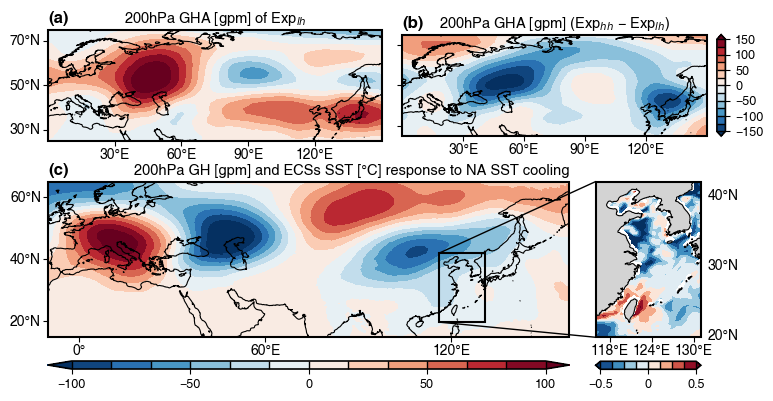

In [28]:
fig = plt.figure(figsize=(8.5, 4))
fig.subplots_adjust(wspace=0.1,hspace=0.3)
gs = GridSpec(2, 3 , figure=fig, width_ratios=[1, 0.50, 0.35], height_ratios=[0.9, 1.25])

ax4 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax4.set_extent([0,150,25,75], crs=ccrs.PlateCarree())
ax4.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs4 = ax4.contourf(da_atm.lon,da_atm.lat,z200_7_convlh-z200_7,levels=np.linspace(-150,150,13),cmap='RdBu_r',extend='both')
gl4 =ax4.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl4.left_labels = True
gl4.bottom_labels = True
gl4.xformatter = LONGITUDE_FORMATTER
gl4.yformatter = LATITUDE_FORMATTER
gl4.xlabel_style = {'size': 10}
gl4.ylabel_style = {'size': 10}
ax4.set_xticks([30,60,90,120])
ax4.set_xticklabels([' ',' ',' ',' '])
ax4.set_yticks([30, 50, 70])
ax4.set_yticklabels([' ',' ',' '])
gl4.xlocator = ticker.FixedLocator([30,60,90,120])
gl4.ylocator = ticker.FixedLocator([30, 50, 70])
ax4.spines['geo'].set_linewidth(1.5)

ax5 = fig.add_subplot(gs[0, 1:], projection=ccrs.PlateCarree(central_longitude=0))
ax5.set_extent([0,150,25,75], crs=ccrs.PlateCarree())
ax5.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs5 = ax5.contourf(da_atm.lon,da_atm.lat,z200_7_convhh-z200_7_convlh,levels=np.linspace(-150,150,13),cmap='RdBu_r',extend='both')
gl5 =ax5.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl5.left_labels = True
gl5.bottom_labels = True
gl5.xformatter = LONGITUDE_FORMATTER
gl5.yformatter = LATITUDE_FORMATTER
gl5.xlabel_style = {'size': 10}
gl5.ylabel_style = {'size': 10}
ax5.set_xticks([30,60,90,120])
ax5.set_xticklabels([' ',' ',' ',' '])
ax5.set_yticks([30, 50, 70])
ax5.set_yticklabels([' ',' ',' '])
gl5.xlocator = ticker.FixedLocator([30,60,90,120])
gl5.ylocator = ticker.FixedLocator([30, 50, 70])
ax5.spines['geo'].set_linewidth(1.5)

sst_na_plot = -1*sst_na
sst_na_plot = np.where(sst_na_plot == 0.0, np.nan, sst_na_plot)
ax6 = fig.add_subplot(gs[1, :2], projection=ccrs.PlateCarree(central_longitude=0))
ax6.set_extent([-10,158,15,65], crs=ccrs.PlateCarree())
ax6.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs6 = ax6.contourf(da_cp.lon,da_cp.lat,z200_cp_na-z200_cp,levels=np.linspace(-100,100,13),cmap='RdBu_r',extend='both')
rect0 = Rectangle((116, 19.8), 15, 22.2, linewidth=1.5, edgecolor='k', facecolor='none')       
ax6.add_patch(rect0) 
gl6 =ax6.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl6.left_labels = True
gl6.bottom_labels = True
gl6.xformatter = LONGITUDE_FORMATTER
gl6.yformatter = LATITUDE_FORMATTER
gl6.xlabel_style = {'size': 10}
gl6.ylabel_style = {'size': 10}
ax6.set_xticks([0,60,120])
ax6.set_xticklabels([' ',' ',' '])
ax6.set_yticks([20, 40, 60])
ax6.set_yticklabels([' ',' ',' '])
gl6.xlocator = ticker.FixedLocator([0,60,120])
gl6.ylocator = ticker.FixedLocator([20, 40, 60])
ax6.spines['geo'].set_linewidth(1.5)

ax7 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=0))
ax7.set_extent([116,131,19.8,42], crs=ccrs.PlateCarree())
ax7.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
ax7.add_feature(cfeature.LAND.with_scale('50m'),facecolor='lightgray',zorder=2)
cs7 = ax7.contourf(ocn_sst_diff.lon,ocn_sst_diff.lat,ocn_sst_diff,levels=np.linspace(-.5,.5,9),cmap='RdBu_r',extend='both')
gl7 =ax7.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl7.right_labels = True
gl7.bottom_labels = True
gl7.xformatter = LONGITUDE_FORMATTER
gl7.yformatter = LATITUDE_FORMATTER
gl7.xlabel_style = {'size': 10}
gl7.ylabel_style = {'size': 10}
ax7.set_xticks([118,124,130])
ax7.set_xticklabels([' ',' ',' '])
# ax7.set_yticks([20, 30, 40])
# ax7.set_yticklabels([' ',' ',' '])
gl7.xlocator = ticker.FixedLocator([118,124,130])
gl7.ylocator = ticker.FixedLocator([20, 30, 40])
ax7.spines['geo'].set_linewidth(1.5)

con1 = ConnectionPatch(
    xyA=(116, 42), coordsA=ax6.transData,      # 起点：ax1 数据坐标
    xyB=(0, 1), coordsB=ax7.transAxes,      # 终点：ax2 轴坐标（右上角）
    # arrowstyle="->",
    linewidth=1
)
con2 = ConnectionPatch(
    xyA=(116, 19.8), coordsA=ax6.transData,      # 起点：ax1 数据坐标
    xyB=(0, 0), coordsB=ax7.transAxes,      # 终点：ax2 轴坐标（右上角）
    # arrowstyle="->",
    linewidth=1
)
fig.add_artist(con1)
fig.add_artist(con2)
cax = add_right_cax_big(ax5,ax5, pad=0.012, width=0.01)
cb =  fig.colorbar(cs5,cax=cax,drawedges=True)
cb.set_ticks([-150,-100,-50,0,50,100,150])
cb.set_ticklabels(['−150','−100','−50','0','50','100','150'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big(ax6,ax6, pad=0.06, width=0.02)
cb =  fig.colorbar(cs6,cax=cax,drawedges=True,orientation='horizontal')
cb.set_ticks([-100,-50,0,50,100])
cb.set_ticklabels(['−100','−50','0','50','100'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_bottom_cax_big(ax7,ax7, pad=0.06, width=0.02)
cb =  fig.colorbar(cs7,cax=cax,drawedges=True,orientation='horizontal')
cb.set_ticks([-0.5,0,0.5])
cb.set_ticklabels(['−0.5','0','0.5'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

ax4.set_title('(a)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax5.set_title('(b)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax6.set_title('(c)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax4.set_title('200hPa GHA [gpm] of Exp$_{lh}$',fontsize=10.5,pad=5)
ax5.set_title('200hPa GHA [gpm] (Exp$_{hh}$ − Exp$_{lh}$)',fontsize=10.5,pad=5)
ax6.set_title('200hPa GH [gpm] and ECSs SST [°C] response to NA SST cooling',fontsize=10.5,pad=5,loc='right')
# fig_format = 'pdf'
fig.savefig('./ERL/Fig5.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')
fig.savefig('./ERL/Fig5.png', format='png', dpi = 300, bbox_inches='tight')

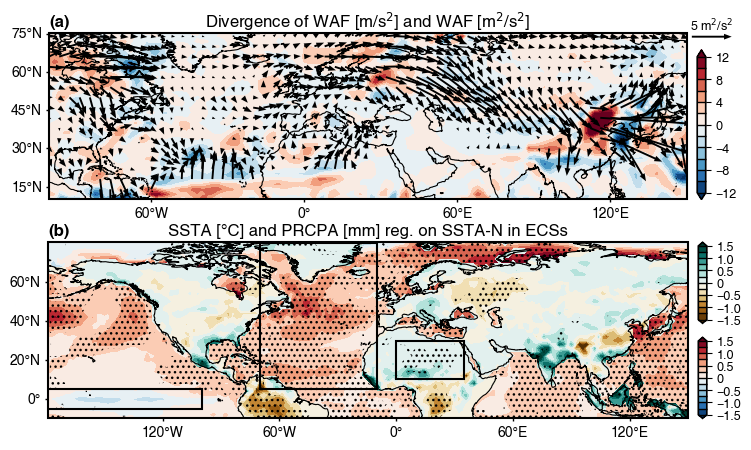

In [29]:
fig = plt.figure(figsize=(8.5, 5))
fig.subplots_adjust(wspace=0.15,hspace=0.25)
gs = GridSpec(2, 1 , figure=fig, height_ratios=[1, 1.06])

ax0 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax0.set_extent([-100,150,10,75.1], crs=ccrs.PlateCarree())
ax0.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs0 = ax0.contourf(lon,lat,divF[-1]*1e6,levels=np.linspace(-12,12,13),cmap='RdBu_r',extend='both')
q = ax0.quiver(lon[::2],lat[10::2],pxo[-1,10::2,::2],pyo[-1,10::2,::2],scale=80,width=0.003,headaxislength=4,headlength=4)
ax0.quiverkey(q,1.0388,0.98,U=5,label='5 m$^2$/s$^2$',labelpos='N',labelsep=0.03,fontproperties={'size':9})
ax0.spines['geo'].set_linewidth(1.5)
gl0 =ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl0.xlabel_style = {'size': 10}
gl0.ylabel_style = {'size': 10}
ax0.set_xticks([-60, 0, 60, 120])
ax0.set_xticklabels([' ',' ',' ',' '])
ax0.set_yticks([15, 30, 45, 60, 75])
ax0.set_yticklabels([' ',' ',' ',' ',' '])
gl0.xlocator = ticker.FixedLocator([-60, 0, 60, 120])
gl0.ylocator = ticker.FixedLocator([15, 30, 45, 60, 75])
ax0.tick_params(axis='both', length=2, width=1)

cax = add_right_cax_big_adj(ax0,ax0, pad=0.012, width=0.01,k=0.9)
cb =  fig.colorbar(cs0,cax=cax,drawedges=True)
cb.set_ticks([-12,-8,-4,0,4,8,12])
cb.set_ticklabels(['−12','−8','−4','0','4','8','12'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax1.set_extent([-179,150,-10,80.5], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs0 = ax1.contourf(lon,lat,slope_rain*1e3,cmap='BrBG',levels=np.linspace(-1.5,1.5,13),extend='both')
cs1 = ax1.contourf(lon,lat,slope_sst,cmap='RdBu_r',levels=np.linspace(-1.5,1.5,13),extend='both')
ax1.contourf(lon, lat, mask_p_sst,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'])
ax1.contourf(lon, lat, mask_p_rain,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['...'])            
ax1.spines['geo'].set_linewidth(1.5)
gl1 =ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl1.left_labels = True
gl1.bottom_labels = True
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
gl1.xlabel_style = {'size': 10}
gl1.ylabel_style = {'size': 10}
ax1.set_xticks([-120, -60, 0, 60, 120])
ax1.set_xticklabels([' ',' ',' ',' ',' '])
ax1.set_yticks([0, 20, 40, 60])
ax1.set_yticklabels([' ',' ',' ',' '])
gl1.xlocator = ticker.FixedLocator([-120, -60, 0, 60, 120])
gl1.ylocator = ticker.FixedLocator([0, 20, 40, 60])
ax1.tick_params(axis='both', length=2, width=1)
rect0 = Rectangle((-70, 5), 60, 75, linewidth=1.5, edgecolor='k', facecolor='none')
rect1 = Rectangle((-180, -5), 80, 10, linewidth=1.5, edgecolor='k', facecolor='none')
rect2 = Rectangle((0, 10), 35, 20, linewidth=1.5, edgecolor='k', facecolor='none')         
ax1.add_patch(rect0)    
ax1.add_patch(rect1)
ax1.add_patch(rect2)
cax = add_right_cax_big_up(ax1,ax1, pad=0.012, width=0.01, k=0.46)
cb =  fig.colorbar(cs0,cax=cax,drawedges=True)
cb.set_ticks([-1.5,-1,-0.5,0,0.5,1,1.5])
cb.set_ticklabels(['−1.5','−1.0','−0.5','0','0.5','1.0','1.5'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

cax = add_right_cax_big_bo(ax1,ax1, pad=0.012, width=0.01, k=0.46)
cb =  fig.colorbar(cs1,cax=cax,drawedges=True)
cb.set_ticks([-1.5,-1,-0.5,0,0.5,1,1.5])
cb.set_ticklabels(['−1.5','−1.0','−0.5','0','0.5','1.0','1.5'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
cb.dividers.set_linewidth(1)

ax0.set_title('(a)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax1.set_title('(b)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax0.set_title('Divergence of WAF [m/s$^2$] and WAF [m$^2$/s$^2$]',fontsize=12,pad=5)
ax1.set_title('SSTA [°C] and PRCPA [mm] reg. on SSTA-N in ECSs',fontsize=12,pad=5)
fig.savefig('./ERL/FigS5.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')
fig.savefig('./ERL/FigS5.png', format='png', dpi = 300, bbox_inches='tight')

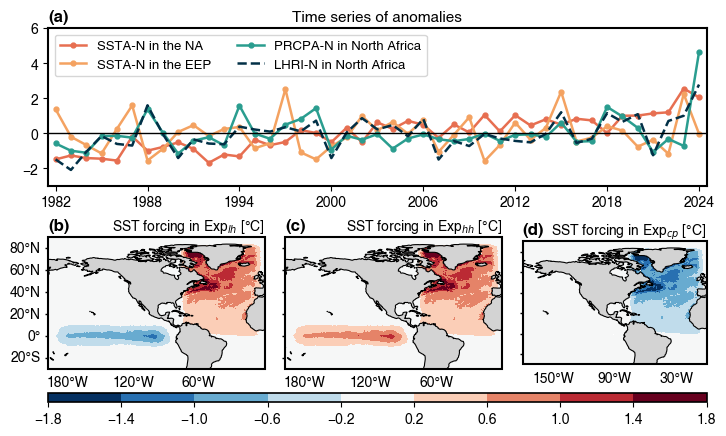

In [34]:
fig = plt.figure(figsize=(8.5, 4.5))
fig.subplots_adjust(wspace=0.1,hspace=0.3)
gs = GridSpec(2, 3 , figure=fig, height_ratios=[1.1, 1], width_ratios=[1, 1, 0.85])

ax3 = fig.add_subplot(gs[0, :])
ax3.plot(np.arange(1982,2025), sst_index,label='SSTA-N in the NA',c='#E76F51',lw=1.8,marker='o',markersize=3.5)
ax3.plot(np.arange(1982,2025), sst_ep_index,label='SSTA-N in the EEP',c='#F4A261',lw=1.8,marker='o',markersize=3.5)
ax3.plot(np.arange(1982,2025), rain_index,label='PRCPA-N in North Africa',c='#2A9D8F',lw=1.8,marker='o',markersize=3.5)
ax3.plot(np.arange(1982,2025), norm(LHI_regmean)[:-1],label='LHRI-N in North Africa',c=(2/255, 48/255, 71/255),ls='--',lw=1.8)
ax3.plot(np.arange(1981,2026), np.zeros_like(np.arange(1981,2026)),c='k',lw=1)
ax3.set_xlim([1981.5,2024.5])
ax3.set_ylim([-3,6])
ax3.set_yticks([-2,0,2,4,6],['−2','0','2','4','6'],fontsize=10)
ax3.set_xticks([1982,1988,1994,2000,2006,2012,2018,2024],[1982,1988,1994,2000,2006,2012,2018,2024],fontsize=10)
# ax3.set_xlabel('Year',fontsize=8,labelpad=0)
# ax3.set_ylabel("Anomaly-N",fontsize=11,labelpad=0)
ax3.legend(loc='upper left',ncol=2,fontsize=9.5)
ax3.spines[['top','bottom','left','right']].set_linewidth(1.5)

ax0 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree(central_longitude=180))
ax0.set_extent([162,359.9,-30,90], crs=ccrs.PlateCarree())
ax0.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=4)
ax0.add_feature(cfeature.LAND.with_scale('110m'),facecolor='lightgray',zorder=2)
ax0.pcolormesh(lon_360,mlat,-1*sst_ep_360+sst_na_360,cmap='RdBu_r',norm=BoundaryNorm(np.linspace(-1.8,1.8,10), ncolors=256, clip=True))
gl0 =ax0.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl0.xlabel_style = {'size': 10}
gl0.ylabel_style = {'size': 10}
# ax0.set_xticks([180, 220, 260, 300, 340])
# ax0.set_xticklabels([' ',' ',' ',' ',' '])
ax0.set_yticks([-20, 0, 20, 40, 60,80])
ax0.set_yticklabels([' ',' ',' ',' ',' ',' '])
# gl0.xlocator = ticker.FixedLocator([180, 220, 260, 300, 340])
gl0.ylocator = ticker.FixedLocator([-20, 0, 20, 40, 60,80])
ax0.tick_params(axis='both', length=2, width=1)
ax0.spines['geo'].set_linewidth(1.5)

ax1 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree(central_longitude=180))
ax1.set_extent([162,359.9,-30,90], crs=ccrs.PlateCarree())
ax1.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=4)
ax1.add_feature(cfeature.LAND.with_scale('110m'),facecolor='lightgray',zorder=2)
cs1 = ax1.pcolormesh(lon_360,mlat,sst_ep_360+sst_na_360,cmap='RdBu_r',norm=BoundaryNorm(np.linspace(-1.8,1.8,10), ncolors=256, clip=True))
gl1 =ax1.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl1.left_labels = True
gl1.bottom_labels = True
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
gl1.xlabel_style = {'size': 10}
gl1.ylabel_style = {'size': 10}
# ax1.set_xticks([180, 220, 260, 300, 340])
# ax1.set_xticklabels([' ',' ',' ',' ',' '])
ax1.set_yticks([-20, 0, 20, 40, 60,80])
ax1.set_yticklabels([' ',' ',' ',' ',' ',' '])
# gl1.xlocator = ticker.FixedLocator([180, 220, 260, 300, 340])
gl1.ylocator = ticker.FixedLocator([-20, 0, 20, 40, 60,80])
ax1.tick_params(axis='both', length=2, width=1)
ax1.spines['geo'].set_linewidth(1.5)

ax2 = fig.add_subplot(gs[1, 2], projection=ccrs.PlateCarree(central_longitude=180))
ax2.set_extent([180,359.9,-30,90], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=4)
ax2.add_feature(cfeature.LAND.with_scale('110m'),facecolor='lightgray',zorder=2)
cs2 = ax2.pcolormesh(lon_360,mlat,-sst_na_360,cmap='RdBu_r',norm=BoundaryNorm(np.linspace(-1.8,1.8,10), ncolors=256, clip=True))
gl2 =ax2.gridlines(crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.0, color='k')
# gl1.left_labels = True
gl2.bottom_labels = True
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER
gl2.xlabel_style = {'size': 10}
gl2.ylabel_style = {'size': 10}
# ax1.set_xticks([180, 220, 260, 300, 340])
# ax1.set_xticklabels([' ',' ',' ',' ',' '])
ax2.set_yticks([-20, 0, 20, 40, 60,80])
ax2.set_yticklabels([' ',' ',' ',' ',' ',' '])
# gl1.xlocator = ticker.FixedLocator([180, 220, 260, 300, 340])
gl2.ylocator = ticker.FixedLocator([-20, 0, 20, 40, 60,80])
ax2.tick_params(axis='both', length=2, width=1)
ax2.spines['geo'].set_linewidth(1.5)

cax = add_bottom_cax_big(ax0,ax2, pad=0.055, width=0.02)
cb =  fig.colorbar(cs1,cax=cax,orientation='horizontal')
# cb.set_ticks([-1.00,-.50,0,.50,1.00])
# cb.set_ticklabels(['−1','−0.5','0','0.5','1'],fontsize=9)
cb.outline.set_edgecolor('black')
cb.outline.set_linewidth(1.2)
# cb.dividers.set_linewidth(1)

ax0.set_title('(b)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax1.set_title('(c)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax2.set_title('(d)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax3.set_title('(a)',fontsize=12,loc='left',fontweight='bold',pad=5)
ax0.set_title('SST forcing in Exp$_{lh}$ [°C]',fontsize=10,pad=5,loc='right')
ax1.set_title('SST forcing in Exp$_{hh}$ [°C]',fontsize=10,pad=5,loc='right')
ax2.set_title('SST forcing in Exp$_{cp}$ [°C]',fontsize=10,pad=5,loc='right')
ax3.set_title('Time series of anomalies',fontsize=11,pad=5)
fig.savefig('./ERL/FigS6.' + fig_format, format=fig_format, dpi = 300, bbox_inches='tight')
fig.savefig('./ERL/FigS6.png', format='png', dpi = 300, bbox_inches='tight')

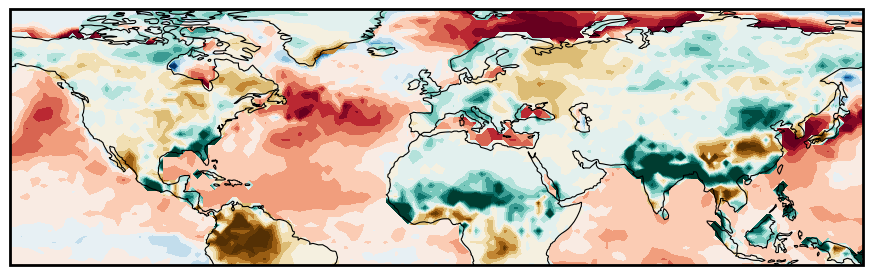

In [566]:
fig = plt.figure(figsize=(11, 7))
# fig.subplots_adjust(hspace=0.15,wspace=0.11)
gs = GridSpec(1, 1 , figure=fig)

ax2 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax2.set_extent([-150,150,-10,80], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE.with_scale('110m'),lw=0.8,zorder=4)
cs1 = ax2.contourf(lon,lat,np.concatenate([((rain_89[-1]-np.mean(rain_89[9:39],0)))[:,721:],
                ((rain_89[-1]-np.mean(rain_89[9:39],0)))[:,:721]],axis=1)*1e3,levels=np.linspace(-3,3,13),cmap='BrBG',extend='both')
cs2 = ax2.contourf(lon,lat,np.concatenate([((sst_ocn_89[-1]-np.mean(sst_ocn_89[9:39],0)))[:,721:],
                ((sst_ocn_89[-1]-np.mean(sst_ocn_89[9:39],0)))[:,:721]],axis=1),levels=np.linspace(-3,3,13),cmap='RdBu_r',extend='both')
ax2.spines[['geo']].set_linewidth(2)
fig.savefig('./fig6-part1.png', format='png', dpi = 300)

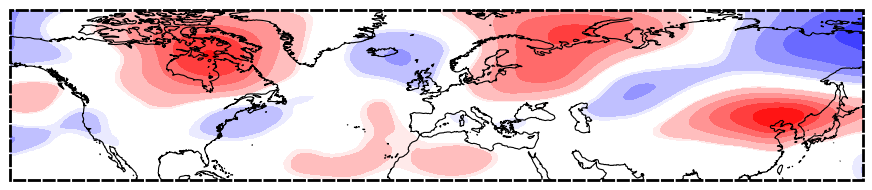

In [42]:
fig = plt.figure(figsize=(11, 7))
# fig.subplots_adjust(hspace=0.15,wspace=0.11)
gs = GridSpec(1, 1 , figure=fig)
gh = np.concatenate([(sel_year(P200_prime,8,9)[-1]/9.8)[:,721:],(sel_year(P200_prime,8,9)[-1]/9.8)[:,:721]],axis=1)
gh = gh-np.mean(gh)
gh[np.abs(gh)<20] = np.nan
ax2 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree(central_longitude=0))
ax2.set_extent([-150,150,20,80], crs=ccrs.PlateCarree())
ax2.add_feature(cfeature.COASTLINE.with_scale('50m'),lw=0.8,zorder=4)
cs2 = ax2.contourf(lon_plot,lat,gh,cmap='bwr',levels=np.linspace(-150,150,13))
ax2.spines[['geo']].set_linewidth(2)
ax2.spines[['geo']].set_linestyle('--')
fig.savefig('./fig6-part2.png', format='png', dpi = 300)